# 02 — Is the fancy/everyday score real?

**Why:** Before training a baby LM on simpler text, check the score isn't measuring something simpler in disguise.

**Three confound checks (§2 frequency, §3 length, §4 grammar), one verdict (§5).** If any check fails, the project pivots.

## 1. Setup

Same imports and corpus paths as notebook 01. Data is already on disk under `data/babylm_2026/strict_small/` — no re-download. We reload the per-source paths and the spaCy pipeline, and define one shared helper (`macroetym_ratio_for_words`) that we'll reuse in §2 and §4.

In [1]:
import sys
import re
import subprocess
import tempfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy

print("Python", sys.version.split()[0])
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("spacy", spacy.__version__)

# Same data layout as notebook 01.
DATA_DIR = (Path.cwd() / ".." / "data" / "babylm_2026" / "strict_small").resolve()
MACROETYM_BIN = str(Path(sys.executable).parent / "macroetym")  # resolve in the venv, not via PATH

SOURCE_ORDER = [
    "switchboard",
    "bnc_spoken",
    "childes",
    "open_subtitles",
    "simple_wiki",
    "gutenberg",
]
source_paths = {s: DATA_DIR / f"{s}.train.txt" for s in SOURCE_ORDER}
for s, p in source_paths.items():
    assert p.exists(), f"missing corpus file: {p}. Run notebook 01 first."

NLP = spacy.load("en_core_web_sm", disable=["parser", "ner"])
NLP.max_length = 50_000_000

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")


def macroetym_family_pct(word_iterable) -> tuple[float, float]:
    """Run macroetym on a wordlist; return (Latinate%, Germanic%) of recognised open-class tokens.

    Macro-Etym takes a file path. We write the words to a tempfile (space-separated),
    call the CLI, and parse its language-family table from stdout.
    """
    words = list(word_iterable)
    if len(words) < 10:
        return (float("nan"), float("nan"))
    with tempfile.NamedTemporaryFile(suffix=".txt", mode="w", delete=False) as f:
        f.write(" ".join(words))
        tmp_path = f.name
    try:
        out = subprocess.run(
            [MACROETYM_BIN, tmp_path],
            capture_output=True, text=True, check=True,
        ).stdout
    finally:
        Path(tmp_path).unlink(missing_ok=True)
    family = {}
    for line in out.splitlines():
        parts = line.split()
        if len(parts) >= 2:
            try:
                family[parts[0]] = float(parts[-1])
            except ValueError:
                continue
    return family.get("Latinate", 0.0), family.get("Germanic", 0.0)


def latinate_ratio(lat: float, ger: float) -> float:
    return lat / (lat + ger) if (lat + ger) > 0 else float("nan")


print("Setup OK. Helper ready: macroetym_family_pct(words) → (lat%, ger%).")

Python 3.13.13
pandas 3.0.3
numpy 2.4.6
spacy 3.8.14


Setup OK. Helper ready: macroetym_family_pct(words) → (lat%, ger%).


## 2. Is "fancy" just "rare"?

**Why:** English's everyday core (*be, have, eat*) is mostly Germanic; its rare technical vocab (*commencement, dichotomy*) is mostly Latinate. So our fancy-vs-everyday gap could secretly be a common-vs-rare gap. (Function words *the, you, and* are auto-dropped by the scoring tool — content words only.)

**How:** Sort content words by global frequency. Bin into top-1k / 1k–5k / 5k–25k / 25k+. Score the fancy-ratio inside each bin per source. Grouped bar chart.

**Read chart:** flat bars across all sources within a bin = no register gap at that frequency level. Spread bars = gap survives.

Global vocabulary size: 117,978 unique types



Per (source, bin) Latinate ratio:
source  switchboard  bnc_spoken  childes  open_subtitles  simple_wiki  \
bin                                                                     
top-1k        0.305       0.311    0.319           0.321        0.318   
1k–5k         0.650       0.629    0.600           0.625        0.632   
5k–25k        0.772       0.717    0.607           0.699        0.718   
25k+          0.839       0.716    0.553           0.691        0.749   

source  gutenberg  
bin                
top-1k      0.313  
1k–5k       0.626  
5k–25k      0.676  
25k+        0.652  


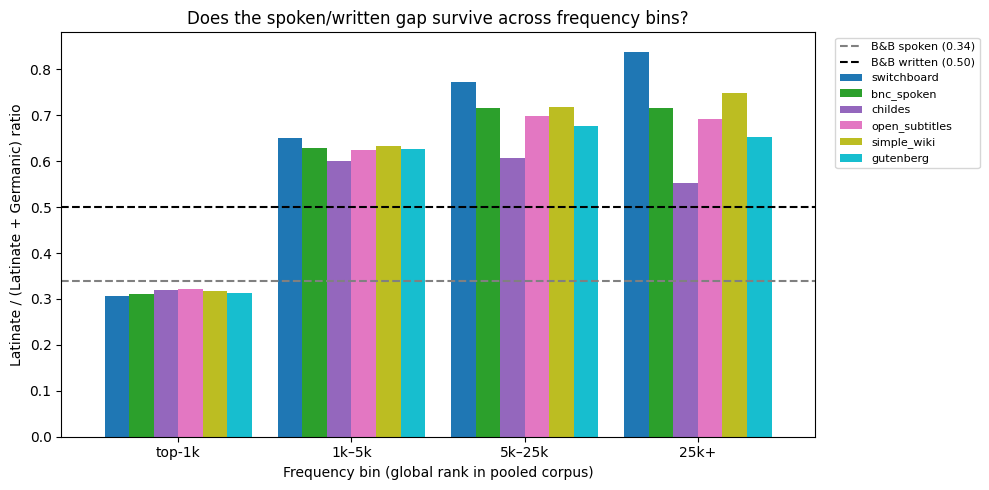

In [2]:
# Step 1: per-source token counts (whitespace + lowercase, alpha tokens only).
source_counts: dict[str, Counter[str]] = {}
for source in SOURCE_ORDER:
    text = source_paths[source].read_text(encoding="utf-8").lower()
    source_counts[source] = Counter(TOKEN_RE.findall(text))

# Step 2: pool to build a global frequency ranking.
global_counts: Counter[str] = Counter()
for c in source_counts.values():
    global_counts.update(c)

ranked = global_counts.most_common()
rank_of = {w: i for i, (w, _) in enumerate(ranked)}
print(f"Global vocabulary size: {len(rank_of):,} unique types")

# Step 3: bin definitions (lo inclusive, hi exclusive).
BINS = [
    (0, 1000, "top-1k"),
    (1000, 5000, "1k–5k"),
    (5000, 25000, "5k–25k"),
    (25000, len(rank_of), "25k+"),
]

# Step 4: for each (source, bin), collect this source's types in that bin and score.
rows = []
for source in SOURCE_ORDER:
    types_in_source = set(source_counts[source].keys())
    for lo, hi, bin_name in BINS:
        words = [w for w in types_in_source if lo <= rank_of.get(w, -1) < hi]
        lat, ger = macroetym_family_pct(words)
        rows.append({
            "source": source,
            "bin": bin_name,
            "n_types": len(words),
            "latinate_pct": lat,
            "germanic_pct": ger,
            "ratio": latinate_ratio(lat, ger),
        })

freq_df = pd.DataFrame(rows)
print("\nPer (source, bin) Latinate ratio:")
print(freq_df.pivot(index="bin", columns="source", values="ratio")[SOURCE_ORDER].reindex([b[2] for b in BINS]).round(3))

# Step 5: plot.
pivot = freq_df.pivot(index="bin", columns="source", values="ratio")[SOURCE_ORDER].reindex([b[2] for b in BINS])
fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot.bar(ax=ax, width=0.85, colormap="tab10")
ax.axhline(0.34, linestyle="--", color="gray", label="B&B spoken (0.34)")
ax.axhline(0.50, linestyle="--", color="black", label="B&B written (0.50)")
ax.set_ylabel("Latinate / (Latinate + Germanic) ratio")
ax.set_xlabel("Frequency bin (global rank in pooled corpus)")
ax.set_title("Does the spoken/written gap survive across frequency bins?")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Result:** top-1k bin sits flat at ~0.31 across all six sources. Gap only opens up in the 1k+ bins.

**Implication:** the score is measuring *vocabulary range*, not register. Common words are equally Germanic for everyone; the spoken/written gap lives entirely in the rare-word tail.

**Caveats:** global ranks are weighted by the bigger sources (Gutenberg + CHILDES ≈ 54% of tokens). Scoring tool drops ~30% of words as unrecognised and is Germanic-biased (notebook 03) — absolute ratios are under-estimates; *direction* of the gap is still valid.

## 3. Is the score just word length in disguise?

**Why:** fancy words tend to be longer (*build* 5 letters vs *construction* 12). If our score and average word length move together perfectly, we could replace the etymology pipeline with one line: `mean(len(word))`.

**How:** mean word length vs fancy-ratio per source (both type-weighted — each unique word counts once). Pearson r across the six sources.

**Read chart:** points on a clean diagonal = length explains the score. Scattered cloud = independent. Thresholds: r > 0.95 length-in-disguise; 0.5–0.95 partial driver; < 0.5 independent.

                mean_word_len  latinate_ratio
source                                       
switchboard             6.304           0.578
bnc_spoken              7.331           0.676
childes                 6.685           0.582
open_subtitles          7.401           0.677
simple_wiki             7.269           0.703
gutenberg               7.483           0.652

Pearson r = 0.872  (n = 6, type-weighted both sides)


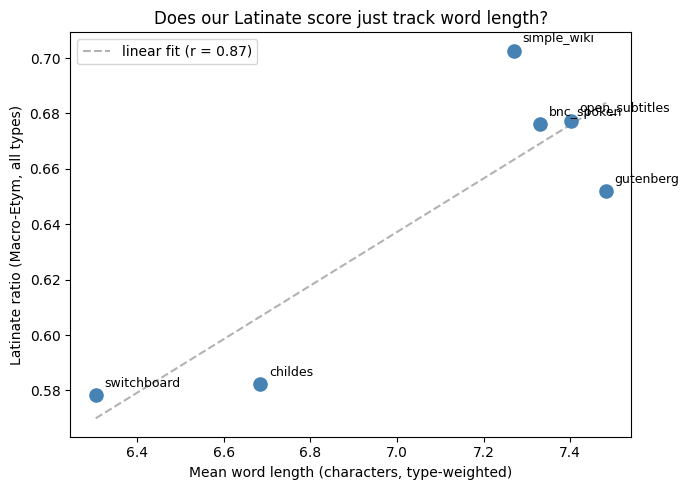

In [3]:
length_rows = []
for source in SOURCE_ORDER:
    counts = source_counts[source]  # already computed in §2
    # Type-weighted mean length: each unique word counts once. Matches the Latinate-ratio
    # denominator (which is also computed over unique types via list(counts.keys())).
    unique_types = list(counts.keys())
    mean_len = sum(len(w) for w in unique_types) / max(len(unique_types), 1)
    lat, ger = macroetym_family_pct(unique_types)
    length_rows.append({
        "source": source,
        "mean_word_len": mean_len,
        "latinate_ratio": latinate_ratio(lat, ger),
    })

length_df = pd.DataFrame(length_rows).set_index("source").loc[SOURCE_ORDER]
print(length_df.round(3))

r = float(np.corrcoef(length_df["mean_word_len"], length_df["latinate_ratio"])[0, 1])
print(f"\nPearson r = {r:.3f}  (n = {len(length_df)}, type-weighted both sides)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(length_df["mean_word_len"], length_df["latinate_ratio"],
           s=90, color="steelblue", zorder=3)
for src in SOURCE_ORDER:
    ax.annotate(src,
                (length_df.loc[src, "mean_word_len"], length_df.loc[src, "latinate_ratio"]),
                xytext=(6, 6), textcoords="offset points", fontsize=9)
m, b = np.polyfit(length_df["mean_word_len"], length_df["latinate_ratio"], 1)
xx = np.linspace(length_df["mean_word_len"].min(), length_df["mean_word_len"].max(), 50)
ax.plot(xx, m * xx + b, "--", color="gray", alpha=0.6, label=f"linear fit (r = {r:.2f})")
ax.set_xlabel("Mean word length (characters, type-weighted)")
ax.set_ylabel("Latinate ratio (Macro-Etym, all types)")
ax.set_title("Does our Latinate score just track word length?")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

**Result:** r = 0.87 (partial-driver zone).

**Implication:** length explains ~75% of the score's variance. Etymology adds residual signal but isn't dominant. Always report mean word length alongside our fancy-ratio so readers can see what each is adding.

**Caveat:** n = 6 sources → 95% CI on r ≈ ±0.20. Direction of evidence, not a precise estimate.

## 4. Where in the grammar does the gap live?

**Why:** textbook says verbs are mostly Germanic across the board (*be, have, go, take, make*), nouns and adjectives carry the Latin borrowing (*commencement, magnificent*). If true, any vocabulary-swap intervention should target nouns and adjectives, not verbs.

**How:** stride-sample 200k tokens per source (every Nth word, not just the first N). POS-tag with spaCy. Compute fancy-ratio per (source × NOUN / VERB / ADJ / ADV).

**Read chart:** if NOUN+ADJ bars sit far above VERB+ADV in every source, textbook holds. If POS bars are bunched, it doesn't.

Per (source, POS) Latinate ratio (token-weighted, stride-sampled across full file):
source  switchboard  bnc_spoken  childes  open_subtitles  simple_wiki  \
pos                                                                     
NOUN          0.676       0.680    0.518           0.651        0.708   
VERB          0.551       0.660    0.493           0.633        0.696   
ADJ           0.579       0.674    0.475           0.642        0.724   
ADV           0.517       0.550    0.400           0.519        0.532   

source  gutenberg  
pos                
NOUN        0.612  
VERB        0.586  
ADJ         0.610  
ADV         0.512  


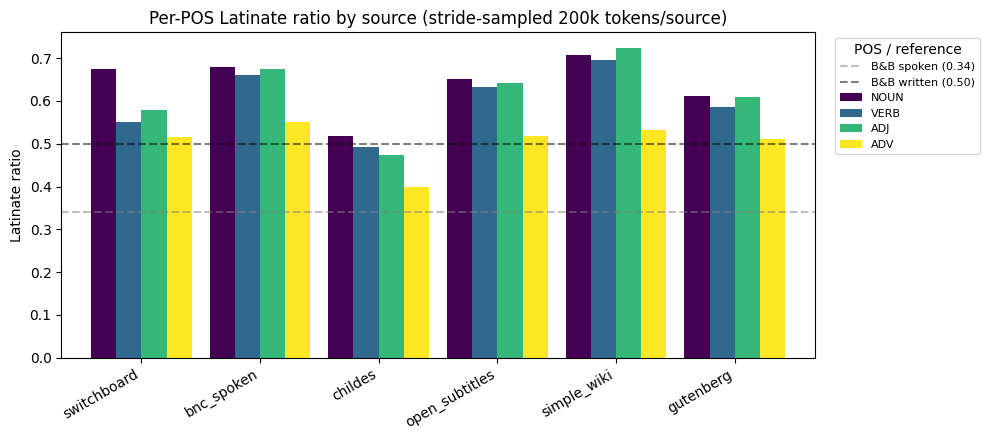

In [4]:
# Sample size per source for POS tagging. Big enough to fill each POS bucket,
# small enough that spaCy stays in the seconds-per-source range. We use a stride
# sample (every Nth token from the whole file) rather than the first N tokens —
# that way Gutenberg isn't dominated by whichever book comes first, and CHILDES
# isn't dominated by whichever age range appears at the top of the file.
SAMPLE_TOKENS_PER_SOURCE = 200_000
POS_TAGS = ["NOUN", "VERB", "ADJ", "ADV"]

pos_rows = []
for source in SOURCE_ORDER:
    all_tokens = source_paths[source].read_text(encoding="utf-8").split()
    stride = max(1, len(all_tokens) // SAMPLE_TOKENS_PER_SOURCE)
    sample = " ".join(all_tokens[::stride][:SAMPLE_TOKENS_PER_SOURCE])
    doc = NLP(sample)
    by_pos: dict[str, list[str]] = {p: [] for p in POS_TAGS}
    for tok in doc:
        if tok.is_alpha and tok.pos_ in POS_TAGS:
            by_pos[tok.pos_].append(tok.lemma_.lower())
    for pos in POS_TAGS:
        lat, ger = macroetym_family_pct(by_pos[pos])
        pos_rows.append({
            "source": source,
            "pos": pos,
            "n_tokens": len(by_pos[pos]),
            "latinate_pct": lat,
            "germanic_pct": ger,
            "ratio": latinate_ratio(lat, ger),
        })

pos_df = pd.DataFrame(pos_rows)
print("Per (source, POS) Latinate ratio (token-weighted, stride-sampled across full file):")
print(pos_df.pivot(index="pos", columns="source", values="ratio")[SOURCE_ORDER].reindex(POS_TAGS).round(3))

pivot = pos_df.pivot(index="source", columns="pos", values="ratio").loc[SOURCE_ORDER][POS_TAGS]
fig, ax = plt.subplots(figsize=(10, 4.5))
pivot.plot.bar(ax=ax, width=0.85, colormap="viridis")
ax.axhline(0.34, linestyle="--", color="gray", alpha=0.5, label="B&B spoken (0.34)")
ax.axhline(0.50, linestyle="--", color="black", alpha=0.5, label="B&B written (0.50)")
ax.set_ylabel("Latinate ratio")
ax.set_xlabel("")
ax.set_title("Per-POS Latinate ratio by source (stride-sampled 200k tokens/source)")
ax.legend(title="POS / reference", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Result:** NOUN, VERB, ADJ all bunched (~0.49–0.72). ADV consistently lowest (most Germanic) across every source. CHILDES is Germanic across all four POS.

**Implication:** textbook prediction is wrong — verbs are *not* a flat-Germanic backbone. Intervention can swap any open-class word; skip adverbs (already Germanic). CHILDES's flat-Germanic pattern is a "directed at children" property, separate from "spoken."

**Caveat:** token-weighted within the sample but no further lemma-frequency weighting. *indicate* counts the same as *go*. A lemma-weighted version is the cleaner follow-up if this finding becomes load-bearing.

## 5. Verdict

| Check | Result | Implication |
|---|---|---|
| **Frequency (§2)** | top-1k bin flat at 0.31 across all sources | Score measures *vocabulary range*, not register. |
| **Length (§3)** | r = 0.87 with mean word length | Length is the dominant signal; etymology adds ~25%. |
| **Per-POS (§4)** | NOUN/VERB/ADJ bunched, ADV lowest, CHILDES outlier | Intervention can swap any open-class word; skip adverbs. |

### Pivot decisions

- **Keep going.** No knockout blows.
- **Reframe.** "Vocabulary range / lexical complexity" — not "register."
- **Don't compare** directly to Bar-Ilan & Berman's 0.34/0.50 reference values — different scale (their hand-counted method used a narrower vocab slice).
- **CHILDES is its own category.** Tag separately from "spoken."
- **Next:** is the tool itself accurate? → notebook 03.